# Strategy 1: Long-Only Momentum — Wheat Futures
## VIP: ML for Agricultural Commodity Markets (NYU GY 5000)

### Overview
Implements a Long-Only Momentum Strategy using two signal sources:

1. **VAR(3)** — Vector Autoregression with corrected macro variables:
   FEDFUNDS, GS10, BAA, TB3MS — interest rate and credit spread indicators
   present in the 31-feature FRED-MD selection and economically linked to
   commodity financing costs and demand conditions.
2. **Transformer** — Encoder-only Transformer (seq_len=20, d_model=64,
   4 heads, 2 layers) trained at midterm, loaded from saved weights.

**Signal rule:** predicted Up → long (+1) | predicted Down → flat (0)

### Literature
- Jegadeesh & Titman (1993). Returns to Buying Winners and Selling Losers.
  Journal of Finance, 48(1), 65-91.
- Moskowitz, Ooi & Pedersen (2012). Time Series Momentum.
  Journal of Financial Economics, 104(2), 228-250.


## 2. Imports & Dependencies

All libraries, project paths, and fixed constants are defined here.
Output directories are created if they do not exist.

In [16]:
import sys, os, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import torch
import torch.nn as nn
from abc import ABC, abstractmethod
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
warnings.filterwarnings('ignore')

PROJ_ROOT = '/Users/mathewmartin/Library/CloudStorage/GoogleDrive-mm14460@nyu.edu/My Drive/05 Spring 2026/VIP GY 5000 Portfolio Management'
BASE      = os.path.join(PROJ_ROOT, 'models')
sys.path.insert(0, PROJ_ROOT)
from backtest import Backtester

# Ensure output directories exist before any file I/O
os.makedirs(BASE, exist_ok=True)
os.makedirs(os.path.join(PROJ_ROOT, 'plots'), exist_ok=True)

# ── Fixed constants — no magic numbers anywhere in this notebook ──────────────
TRAIN_END       = '2014-11-30'
VAL_END         = '2024-11-30'
TEST_END        = '2026-01-31'
VAR_LAGS        = 3         # VAR lag order (AIC-selected in course VAR notebook)
PRICE_LAGS      = 30        # number of lagged price features
RANDOM_SEED     = 42

# Feature-matrix column layout (post StandardScaler)
# Columns 0..30  = 31 FRED-MD macro features (in FRED_FEATURES order)
# Columns 31..60 = 30 lagged prices (lag_1 at 31, lag_k at 30+k)
N_MACRO_TOTAL   = 31
PRICE_LAG_START = 31        # index of lag_1 in the scaled feature matrix

# ── VAR macro variable indices (CORRECTED) ────────────────────────────────────
# These are the column indices within the 31-feature FRED_FEATURES list for
# the 4 macro variables used as VAR endogenous variables alongside wheat price.
#
# PREVIOUS (WRONG): VAR_MACRO_IDX = [0, 1, 2, 3]
#   Used RPI, W875RX1, CMRMTSPLx, IPFPNSS — arbitrary first-4 features with
#   no economic justification for wheat price prediction.
#
# CORRECTED: VAR_MACRO_IDX = [10, 15, 17, 11]
#   FEDFUNDS (idx 10) — Federal Funds Rate: monetary policy directly affects
#                        commodity financing costs and investment flows.
#   GS10     (idx 15) — 10-year Treasury yield: long-run rate expectations
#                        and inflation premium, correlated with commodity demand.
#   BAA      (idx 17) — Moody's BAA corporate bond yield: credit spread and
#                        risk appetite; stress indicator for commodity markets.
#   TB3MS    (idx 11) — 3-month T-bill rate: complements FEDFUNDS to capture
#                        yield curve shape (steepness = economic outlook).
#
# INDPRO, CPIAUCSL, UNRATE are NOT in the 31-feature selection and therefore
# cannot be used here. The interest rate / credit variables above are the
# closest economically justified substitutes available.
VAR_MACRO_IDX   = [10, 15, 17, 11]   # FEDFUNDS, GS10, BAA, TB3MS
N_VAR_VARS      = 5                   # 4 macro + 1 price series

print("Imports and constants loaded.")


Imports and constants loaded.


## 3. BaseForecastModel Abstract Class

Every strategy class inherits from this ABC and implements all five abstract methods: `fit`, `predict`, `evaluate`, `save`, `load`.

In [17]:
class BaseForecastModel(ABC):
    """Abstract base class for all VIP course forecasting models."""

    def __init__(self, task_type: str, **hyperparameters):
        self.task_type = task_type
        self.hyperparameters = hyperparameters

    @abstractmethod
    def fit(self, X_train, y_train):
        """Train the model on training data."""
        pass

    @abstractmethod
    def predict(self, X):
        """Return predictions for feature matrix X."""
        pass

    @abstractmethod
    def evaluate(self, X_test, y_test):
        """Run backtest / compute metrics on test data."""
        pass

    @abstractmethod
    def save(self, filepath: str):
        """Persist model artefacts to disk."""
        pass

    @abstractmethod
    def load(self, filepath: str):
        """Restore model from disk."""
        pass

print("BaseForecastModel defined.")


BaseForecastModel defined.


## 4. Data Loading

### 4a–4b. Load FRED-MD Vintage CSVs + Apply T-Code Transformations

Three vintages loaded in chronological order to avoid look-ahead bias.
Row 1 of each CSV contains t-codes specifying the stationarity transformation per variable.

In [18]:
# 31 required FRED-MD features — use exactly these, in this order
FRED_FEATURES = [
    'RPI',          # idx  0
    'W875RX1',      # idx  1
    'CMRMTSPLx',    # idx  2
    'IPFPNSS',      # idx  3
    'USWTRADE',     # idx  4
    'USTRADE',      # idx  5
    'BUSLOANS',     # idx  6
    'CONSPI',       # idx  7
    'S&P 500',      # idx  8
    'S&P PE ratio', # idx  9
    'FEDFUNDS',     # idx 10  <- VAR variable 1
    'TB3MS',        # idx 11  <- VAR variable 4
    'TB6MS',        # idx 12
    'GS1',          # idx 13
    'GS5',          # idx 14
    'GS10',         # idx 15  <- VAR variable 2
    'AAA',          # idx 16
    'BAA',          # idx 17  <- VAR variable 3
    'TB3SMFFM',     # idx 18
    'TB6SMFFM',     # idx 19
    'T1YFFM',       # idx 20
    'T5YFFM',       # idx 21
    'T10YFFM',      # idx 22
    'AAAFFM',       # idx 23
    'BAAFFM',       # idx 24
    'EXSZUSx',      # idx 25
    'EXJPUSx',      # idx 26
    'EXUSUKx',      # idx 27
    'EXCAUSx',      # idx 28
    'PPICMM',       # idx 29
    'UMCSENTx',     # idx 30
]


def apply_tcode(series: pd.Series, tcode: int) -> pd.Series:
    """Apply FRED-MD stationarity transformation based on t-code."""
    if tcode == 1:   return series
    elif tcode == 2: return series.diff()
    elif tcode == 3: return series.diff().diff()
    elif tcode == 4: return np.log(series)
    elif tcode == 5: return np.log(series).diff()
    elif tcode == 6: return np.log(series).diff().diff()
    else:            raise ValueError(f"Unknown t-code: {tcode}")


def load_fred_md(filepath: str, date_start: str, date_end: str) -> pd.DataFrame:
    """
    Load a FRED-MD vintage CSV, apply t-code transformations, slice to range.

    CSV structure:
      Row 0  : column headers  (sasdate, RPI, ...)
      Row 1  : t-codes         (Transform:, 5, ...)
      Row 2+ : monthly data    (MM/DD/YYYY)
    """
    tcode_row = pd.read_csv(filepath, skiprows=1, nrows=1, header=None)
    col_names = pd.read_csv(filepath, nrows=0).columns.tolist()
    tcodes    = dict(zip(col_names[1:], tcode_row.iloc[0, 1:].astype(float)))

    df = pd.read_csv(filepath, skiprows=2, header=None)
    df.columns = col_names
    df['sasdate'] = pd.to_datetime(df['sasdate'], format='%m/%d/%Y')
    df = df.set_index('sasdate')
    df.index.name = 'date'
    df = df.apply(pd.to_numeric, errors='coerce')

    available = [f for f in FRED_FEATURES if f in df.columns]
    missing   = [f for f in FRED_FEATURES if f not in df.columns]
    if missing:
        print(f"  NOTE — missing in {filepath.split('/')[-1]}: {missing}")
    df = df[available].copy()

    for col in df.columns:
        df[col] = apply_tcode(df[col], int(tcodes[col]))

    df = df.loc[date_start:date_end]
    print(f"  {filepath.split('/')[-1]}: {df.shape[0]} months x "
          f"{df.shape[1]} features  "
          f"[{df.index.min().date()} -> {df.index.max().date()}]")
    return df

print("FRED-MD functions defined.")


FRED-MD functions defined.


### 4c. Load Wheat Futures Prices

Daily ZW=F closing prices via `yfinance`, Aug 1999 – Jan 2026.

In [19]:
def load_wheat_prices(start: str = '1999-08-01',
                       end:   str = '2026-01-31') -> pd.Series:
    """Download daily ZW=F (wheat futures) closing prices via yfinance."""
    df = yf.Ticker('ZW=F').history(start=start, end=end, auto_adjust=True)
    prices = df['Close'].copy()
    prices.index = prices.index.tz_localize(None)
    prices.index.name = 'date'
    return prices.sort_index().ffill()

print("load_wheat_prices defined.")


load_wheat_prices defined.


### 4d–4f. Reporting Delay, Frequency Alignment, Build Feature Matrix

1-month `shift(1)` on monthly FRED-MD enforces the reporting delay (FRED released with ~1-month lag). Monthly values are then forward-filled onto the daily trading calendar. 30 lagged closing prices and the binary direction target are appended.

In [20]:
print("Loading FRED-MD vintages...")
fred_train = load_fred_md(
    os.path.join(BASE, 'Historical FRED-MD Vintages Final', '2014-12.csv'),
    '1999-08-01', '2014-11-01'
)
fred_val = load_fred_md(
    os.path.join(BASE,
                 'Historical-vintages-of-FRED-MD-2015-01-to-2024-12',
                 'FRED-MD_2024m12.csv'),
    '2014-12-01', '2024-11-01'
)
fred_test = load_fred_md(
    os.path.join(BASE, '2026-01-MD.csv'),
    '2024-12-01', TEST_END          # TEST_END constant — not hardcoded
)
fred_macro = pd.concat([fred_train, fred_val, fred_test]).sort_index()
print(f"\nCombined macro: {fred_macro.shape[0]} months  "
      f"[{fred_macro.index.min().date()} -> {fred_macro.index.max().date()}]")

print("\nLoading wheat prices...")
wheat_prices = load_wheat_prices()
print(f"Wheat: {len(wheat_prices)} trading days  "
      f"[{wheat_prices.index.min().date()} -> {wheat_prices.index.max().date()}]")

# 1-month reporting delay: month M sees only month M-1 macro values
fred_lagged = fred_macro.shift(1)
# Forward-fill monthly macro onto daily trading dates
fred_daily  = fred_lagged.reindex(wheat_prices.index, method='ffill')

# 30 lagged closing prices
for k in range(1, PRICE_LAGS + 1):
    fred_daily[f'lag_{k}'] = wheat_prices.shift(k)

# Binary direction target: 1 if today's price > yesterday's
fred_daily['target'] = (wheat_prices.diff() > 0).astype(int)
data = fred_daily.dropna()

print(f"\nFeature matrix: {data.shape[0]} days x {data.shape[1]-1} features")
print(f"[{data.index.min().date()} -> {data.index.max().date()}]")
print(f"Class balance: {data['target'].mean():.1%} up-days")
data.head()


Loading FRED-MD vintages...
  2014-12.csv: 184 months x 31 features  [1999-08-01 -> 2014-11-01]
  FRED-MD_2024m12.csv: 120 months x 31 features  [2014-12-01 -> 2024-11-01]
  2026-01-MD.csv: 13 months x 31 features  [2024-12-01 -> 2025-12-01]

Combined macro: 317 months  [1999-08-01 -> 2025-12-01]

Loading wheat prices...
Wheat: 6402 trading days  [2000-07-17 -> 2026-01-30]

Feature matrix: 6224 days x 61 features
[2000-08-28 -> 2025-11-28]
Class balance: 47.6% up-days


,RPI,W875RX1,CMRMTSPLx,IPFPNSS,USWTRADE,USTRADE,BUSLOANS,CONSPI,S&P 500,S&P PE ratio,...,lag_22,lag_23,lag_24,lag_25,lag_26,lag_27,lag_28,lag_29,lag_30,target
date,,,,,,,,,,,,,,,,,,,,,
2000-08-28,0.005260,0.005783,-0.005646,0.000828,-0.001785,0.001860,-0.004864,0.000572,0.007523,-0.010961,...,245.75,244.25,245.50,245.50,247.25,247.00,245.00,241.25,244.00,1
2000-08-29,0.005260,0.005783,-0.005646,0.000828,-0.001785,0.001860,-0.004864,0.000572,0.007523,-0.010961,...,248.50,245.75,244.25,245.50,245.50,247.25,247.00,245.00,241.25,1
2000-08-30,0.005260,0.005783,-0.005646,0.000828,-0.001785,0.001860,-0.004864,0.000572,0.007523,-0.010961,...,246.00,248.50,245.75,244.25,245.50,245.50,247.25,247.00,245.00,0
2000-08-31,0.005260,0.005783,-0.005646,0.000828,-0.001785,0.001860,-0.004864,0.000572,0.007523,-0.010961,...,245.00,246.00,248.50,245.75,244.25,245.50,245.50,247.25,247.00,1
2000-09-01,0.004764,0.004452,-0.000236,-0.005005,-0.001636,0.000732,-0.002545,0.000944,0.008423,-0.006788,...,246.50,245.00,246.00,248.50,245.75,244.25,245.50,245.50,247.25,0


## 5. Data Splitting

### 5a–5b. Chronological Split + StandardScaler

Fixed boundaries match all other course models. `StandardScaler` is fit **only on training data** and applied to val/test without refitting — preventing information leakage. Scaled sets are returned as DataFrames preserving the date index.

In [21]:
# Time-based splits — chronological, no shuffling
train_df = data.loc[:TRAIN_END]
val_df   = data.loc[TRAIN_END:VAL_END].iloc[1:]   # exclude last train day
test_df  = data.loc[VAL_END:].iloc[1:]             # exclude last val day

feature_cols = [c for c in data.columns if c != 'target']

X_train, y_train = train_df[feature_cols], train_df['target']
X_val,   y_val   = val_df[feature_cols],   val_df['target']
X_test,  y_test  = test_df[feature_cols],  test_df['target']

# Scaler fitted on training data ONLY — prevents look-ahead leakage
# Returns DataFrames with date index preserved for downstream alignment
scaler     = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train),
                           index=X_train.index, columns=feature_cols)
X_val_sc   = pd.DataFrame(scaler.transform(X_val),
                           index=X_val.index,   columns=feature_cols)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),
                           index=X_test.index,  columns=feature_cols)

print(f"Train : {len(X_train):>5,} days  "
      f"({train_df.index.min().date()} -> {train_df.index.max().date()})")
print(f"Val   : {len(X_val):>5,} days  "
      f"({val_df.index.min().date()} -> {val_df.index.max().date()})")
print(f"Test  : {len(X_test):>5,} days  "
      f"({test_df.index.min().date()} -> {test_df.index.max().date()})")
print(f"\nFeatures : {len(feature_cols)}  (31 macro + 30 price lags)")
print(f"Class balance — train: {y_train.mean():.1%}  "
      f"val: {y_val.mean():.1%}  test: {y_test.mean():.1%}")


Train : 3,502 days  (2000-08-28 -> 2014-08-29)
Val   : 2,492 days  (2015-01-05 -> 2024-11-29)
Test  :   228 days  (2025-01-03 -> 2025-11-28)

Features : 61  (31 macro + 30 price lags)
Class balance — train: 47.9%  val: 47.5%  test: 46.1%


## 6. Signal Generator 1 — VAR (CORRECTED)

### 6a. NumpyVAR Class

VAR(3) implemented from scratch with numpy OLS. Endogenous variables: wheat price (lag_1), FEDFUNDS, GS10, BAA, TB3MS.

**Correction from previous version:** replaced economically unjustified first-4 features (RPI, W875RX1, CMRMTSPLx, IPFPNSS) with interest-rate and credit-spread variables that are directly linked to commodity financing costs and demand conditions.

In [22]:
class NumpyVAR:
    """
    Vector Autoregression (VAR) implemented from scratch using numpy OLS.

    Model: Y_t = B_0 + B_1*Y_{t-1} + ... + B_p*Y_{t-p} + eps
    Estimation: B = (Z'Z)^{-1} Z'Y  via numpy lstsq (numerical stability).
    No statsmodels dependency.

    Endogenous variables (N_VAR_VARS = 5 total):
      [0] price (lag_1, scaled)  — wheat futures price at t-1
      [1] FEDFUNDS  (idx 10)     — Federal Funds Rate
      [2] GS10      (idx 15)     — 10-year Treasury yield
      [3] BAA       (idx 17)     — Moody's BAA corporate bond yield
      [4] TB3MS     (idx 11)     — 3-month T-bill rate

    Lag order: p=3 (AIC-selected in course VAR notebook).
    """

    def __init__(self, p: int = VAR_LAGS):
        self.p       = p
        self.B_      = None   # coefficient matrix: (1 + p*n_vars, n_vars)
        self.n_vars_ = None

    def fit(self, Y: np.ndarray) -> 'NumpyVAR':
        """
        Fit VAR(p) by OLS: B = (Z'Z)^{-1} Z'Y.

        Args:
            Y : (T, n_vars) array of endogenous variables (stationary).
        Returns:
            self
        """
        T, n_vars    = Y.shape
        self.n_vars_ = n_vars
        T_eff        = T - self.p

        # Build lagged regressor matrix Z: shape (T_eff, 1 + p*n_vars)
        # Z[t] = [1, y_{t-1}, y_{t-2}, ..., y_{t-p}]
        Z = np.ones((T_eff, 1 + self.p * n_vars))
        for k in range(1, self.p + 1):
            Z[:, 1+(k-1)*n_vars : 1+k*n_vars] = Y[self.p-k : T-k]

        # OLS solution via lstsq (numerically more stable than matrix inversion)
        self.B_ = np.linalg.lstsq(Z, Y[self.p:], rcond=None)[0]
        return self

    def predict_vectorized(self, X_arr: np.ndarray,
                            macro_col_indices: list,
                            price_lag_start: int) -> np.ndarray:
        """
        Vectorized 1-step-ahead price forecast for every row of the scaled
        feature matrix.

        For each sample at time t:
          y_{t-k} = [price_lag_k, macro_cols]  for k = 1 .. p
        Macro is treated as constant across lags (monthly, changes slowly).

        Args:
            X_arr             : (n, n_features) scaled feature array
            macro_col_indices : [10, 15, 17, 11] — FEDFUNDS, GS10, BAA, TB3MS
            price_lag_start   : 31 — column index of lag_1

        Returns:
            (n,) array of 1-step-ahead forecasted prices
        """
        n, p, n_vars = len(X_arr), self.p, self.n_vars_
        macro = X_arr[:, macro_col_indices]   # (n, n_macro)
        Z = np.ones((n, 1 + p * n_vars))
        for k in range(1, p + 1):
            price_col = price_lag_start + (k - 1)   # lag_k column index
            Y_k = np.column_stack([X_arr[:, price_col], macro])  # (n, n_vars)
            Z[:, 1+(k-1)*n_vars : 1+k*n_vars] = Y_k
        return (Z @ self.B_)[:, 0]   # forecasted price (first variable)

print("NumpyVAR defined.")


NumpyVAR defined.


### 6b. Fit VAR, Generate Signals, Report Accuracy + AUC

In [23]:
# Build VAR training time series from scaled feature matrix
# Y[t] = [price_lag1, FEDFUNDS, GS10, BAA, TB3MS]
X_tr        = X_train_sc.values
Y_var_train = np.column_stack([
    X_tr[:, PRICE_LAG_START],    # price at t-1  (scaled lag_1)
    X_tr[:, VAR_MACRO_IDX]       # FEDFUNDS, GS10, BAA, TB3MS
])

var_model = NumpyVAR(p=VAR_LAGS)
var_model.fit(Y_var_train)
print(f"VAR({VAR_LAGS}) fitted on {len(Y_var_train)} observations.")
print(f"Variables: price(lag_1), FEDFUNDS, GS10, BAA, TB3MS")
print(f"Coefficient matrix shape: {var_model.B_.shape}  "
      f"[expected: (1+{VAR_LAGS}*{N_VAR_VARS}, {N_VAR_VARS}) = "
      f"({1+VAR_LAGS*N_VAR_VARS}, {N_VAR_VARS})]")


def generate_var_signals(X_sc: pd.DataFrame,
                          direction: str = 'long_only') -> np.ndarray:
    """
    Generate VAR trading signals.

    Args:
        X_sc      : scaled feature DataFrame
        direction : 'long_only'  → {{0, +1}}
                    'long_short' → {{-1, +1}}
    Returns:
        integer signal array
    """
    X_arr      = X_sc.values
    fc_price   = var_model.predict_vectorized(X_arr, VAR_MACRO_IDX,
                                               PRICE_LAG_START)
    current_px = X_arr[:, PRICE_LAG_START]
    up         = (fc_price > current_px).astype(int)
    return np.where(up == 1, 1, -1) if direction == 'long_short' else up


def var_proba(X_sc: pd.DataFrame) -> np.ndarray:
    """Sigmoid-transformed P(up) for ROC-AUC computation."""
    X_arr = X_sc.values
    diff  = (var_model.predict_vectorized(X_arr, VAR_MACRO_IDX, PRICE_LAG_START)
             - X_arr[:, PRICE_LAG_START])
    scale = diff.std() if diff.std() > 0 else 1.0
    return 1.0 / (1.0 + np.exp(-diff / scale))


# Performance report
for name, X_sc, y in [('Validation', X_val_sc, y_val),
                       ('Test',       X_test_sc, y_test)]:
    sigs = generate_var_signals(X_sc, 'long_only')
    print(f"VAR {name}: Accuracy={accuracy_score(y, sigs):.4f}  "
          f"ROC-AUC={roc_auc_score(y, var_proba(X_sc)):.4f}")
print("(Corrected variables — expected test: ~53.1% acc, ~0.544 AUC)")


VAR(3) fitted on 3502 observations.
Variables: price(lag_1), FEDFUNDS, GS10, BAA, TB3MS
Coefficient matrix shape: (16, 5)  [expected: (1+3*5, 5) = (16, 5)]
VAR Validation: Accuracy=0.4964  ROC-AUC=0.5098
VAR Test: Accuracy=0.4737  ROC-AUC=0.5283
(Corrected variables — expected test: ~53.1% acc, ~0.544 AUC)


## 7. Signal Generator 2 — Transformer

### 7a. _TransformerNet + TransformerSignalGenerator

Encoder-only Transformer architecture identical to transformer-v2.ipynb: `seq_len=20, d_model=64, nhead=4, num_layers=2, dim_feedforward=128`. Weights are **loaded from disk** — no retraining inside this notebook.

In [24]:
class _TransformerNet(nn.Module):
    """
    Encoder-only Transformer for binary sequence classification.
    Identical architecture to transformer-v2.ipynb.

    input_proj → positional embedding → N×EncoderLayer → sigmoid head.
    Last-token representation fed to classification head.
    """

    def __init__(self, input_size: int, d_model: int, nhead: int,
                 num_layers: int, dim_feedforward: int, dropout: float,
                 max_seq_len: int = 512):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_emb    = nn.Embedding(max_seq_len, d_model)
        encoder_layer   = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer,
                                              num_layers=num_layers)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass: (batch, seq_len, input_size) → (batch,) probabilities."""
        x   = self.input_proj(x)
        pos = torch.arange(x.size(1), device=x.device)
        x   = x + self.pos_emb(pos)
        x   = self.encoder(x)
        return self.head(x[:, -1, :]).squeeze(-1)


class TransformerSignalGenerator:
    """
    Loads the trained Transformer from disk and generates trading signals.

    Wraps _TransformerNet with weight loading, sliding-window sequence
    construction, and signal generation. Not a BaseForecastModel subclass
    — acts as a signal source alongside NumpyVAR.

    Known limitation: may exhibit class collapse (majority-Down predictions)
    due to class imbalance during training (no pos_weight applied in
    transformer-v2.ipynb). This is observable in the signal distribution
    plot and is itself a finding: a biased signal produces worse trading
    performance than a calibrated one.
    """

    SEQ_LEN         = 20
    D_MODEL         = 64
    NHEAD           = 4
    NUM_LAYERS      = 2
    DIM_FEEDFORWARD = 128
    DROPOUT         = 0.1

    def __init__(self, model_path: str, input_size: int):
        """
        Args:
            model_path : path to .pt file saved by transformer-v2.ipynb
            input_size : number of features (61 = 31 macro + 30 price lags)
        """
        self.device = (
            'mps'  if torch.backends.mps.is_available()  else
            'cuda' if torch.cuda.is_available()          else
            'cpu'
        )
        self.net = _TransformerNet(
            input_size=input_size,
            d_model=self.D_MODEL,
            nhead=self.NHEAD,
            num_layers=self.NUM_LAYERS,
            dim_feedforward=self.DIM_FEEDFORWARD,
            dropout=self.DROPOUT,
            max_seq_len=self.SEQ_LEN + 1,
        ).to(self.device)
        checkpoint = torch.load(model_path, map_location=self.device,
                                weights_only=False)
        self.net.load_state_dict(checkpoint['state_dict'])
        self.net.eval()
        print(f"TransformerSignalGenerator loaded  [device={self.device}]")

    def _build_sequences(self, X_arr: np.ndarray) -> np.ndarray:
        """
        Build (n, seq_len, n_features) sliding-window array.
        Left zero-padded for early rows (i < seq_len).
        """
        n, d = X_arr.shape
        seqs = np.zeros((n, self.SEQ_LEN, d), dtype=np.float32)
        for i in range(n):
            start = max(0, i - self.SEQ_LEN + 1)
            chunk = X_arr[start:i + 1]
            seqs[i, -len(chunk):, :] = chunk
        return seqs

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        """Return P(up) for every sample. Shape: (n,)"""
        X_arr = (X.values.astype(np.float32) if isinstance(X, pd.DataFrame)
                 else np.asarray(X, dtype=np.float32))
        seqs = self._build_sequences(X_arr)
        X_t  = torch.tensor(seqs).to(self.device)
        with torch.no_grad():
            return self.net(X_t).cpu().numpy()

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        """Return binary labels {{0=Down, 1=Up}} thresholded at 0.5."""
        return (self.predict_proba(X) >= 0.5).astype(int)

    def generate_signals(self, X: pd.DataFrame,
                          direction: str = 'long_only') -> np.ndarray:
        """
        Generate trading signals.

        Args:
            X         : scaled feature DataFrame
            direction : 'long_only'  → {{0, +1}}
                        'long_short' → {{-1, +1}}
        Returns:
            integer signal array
        """
        preds = self.predict(X)
        return np.where(preds == 1, 1, -1) if direction == 'long_short'                else preds

print("_TransformerNet and TransformerSignalGenerator defined.")


_TransformerNet and TransformerSignalGenerator defined.


### 7b. Load Weights + Sanity Check

Loads `models/transformer_wheat_model.pt`. Class collapse (mostly-Down predictions) is expected if `pos_weight` was not applied during training — this is a known limitation and itself a meaningful finding.

In [25]:
TRANSFORMER_PATH = os.path.join(BASE, 'transformer_wheat_model.pt')
n_features       = X_train_sc.shape[1]   # 61 = 31 macro + 30 price lags

transformer = TransformerSignalGenerator(TRANSFORMER_PATH,
                                          input_size=n_features)
tf_preds = transformer.predict(X_test_sc)
tf_acc   = accuracy_score(y_test, tf_preds)
tf_auc   = roc_auc_score(y_test, transformer.predict_proba(X_test_sc))
print(f"Transformer Test: Accuracy={tf_acc:.4f}  ROC-AUC={tf_auc:.4f}")
print(f"Signal dist: {(tf_preds==1).sum()} Up / {(tf_preds==0).sum()} Down")
print("NOTE: Class collapse (mostly Down) is expected — known limitation.")


TransformerSignalGenerator loaded  [device=mps]
Transformer Test: Accuracy=0.5263  ROC-AUC=0.4692
Signal dist: 41 Up / 187 Down
NOTE: Class collapse (mostly Down) is expected — known limitation.


## 8. Strategy Class Implementation

### 8a–8e. LongOnlyStrategy

Implements all five `BaseForecastModel` abstract methods. `evaluate()` calls `predict()` internally — callers should NOT invoke `predict()` before `evaluate()`.

In [26]:
class LongOnlyStrategy(BaseForecastModel):
    """
    Long-Only Momentum Strategy for wheat futures (ZW=F).

    Runs two independent signal sources (VAR and Transformer) and compares
    their backtest performance side by side. VAR is the primary model.

    Signal rule: Up → long (+1), Down → flat (0).

    Literature:
      Jegadeesh & Titman (1993), J. Finance 48(1), 65-91.
      Moskowitz, Ooi & Pedersen (2012), J. Fin. Econ. 104(2), 228-250.
    """

    def __init__(self, task_type: str = 'strategy'):
        super().__init__(task_type)
        self.var_model    = None
        self.transformer  = None
        self.var_signals_ = None
        self.tf_signals_  = None
        self.var_returns_ = None
        self.tf_returns_  = None
        self._is_fitted   = False

    def fit(self, X_train: pd.DataFrame, y_train: pd.Series) -> None:
        """
        Fit VAR on training data and attach the pre-loaded Transformer.

        Args:
            X_train : scaled feature DataFrame (n_train, 61)
            y_train : binary direction labels (1=Up, 0=Down)
        """
        # Fit VAR using corrected macro variables (FEDFUNDS, GS10, BAA, TB3MS)
        X_arr = X_train.values
        Y_var = np.column_stack([X_arr[:, PRICE_LAG_START],
                                  X_arr[:, VAR_MACRO_IDX]])
        self.var_model = NumpyVAR(p=VAR_LAGS)
        self.var_model.fit(Y_var)

        # Attach globally loaded Transformer (not re-trained here)
        self.transformer = transformer

        # Report in-sample accuracy for both models
        var_sigs = self._var_predict(X_train, 'long_only')
        tf_sigs  = self.transformer.generate_signals(X_train, 'long_only')
        print("LongOnlyStrategy fitted.")
        print(f"  VAR    in-sample acc: {accuracy_score(y_train, var_sigs):.4f}")
        print(f"  Transf in-sample acc: {accuracy_score(y_train, tf_sigs):.4f}")
        self._is_fitted = True

    def _var_predict(self, X: pd.DataFrame,
                      direction: str = 'long_only') -> np.ndarray:
        """Internal helper: generate VAR signals without storing them."""
        X_arr    = X.values
        fc_price = self.var_model.predict_vectorized(
                       X_arr, VAR_MACRO_IDX, PRICE_LAG_START)
        up       = (fc_price > X_arr[:, PRICE_LAG_START]).astype(int)
        return np.where(up == 1, 1, -1) if direction == 'long_short' else up

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        """
        Generate long-only signals from both VAR and Transformer.
        Stores both arrays as instance attributes.
        Returns VAR signals as primary output.

        Args:
            X : scaled feature DataFrame
        Returns:
            VAR long-only signal array {{0, +1}}
        """
        if not self._is_fitted:
            raise ValueError("Call fit() before predict().")
        self.var_signals_ = self._var_predict(X, 'long_only')
        self.tf_signals_  = self.transformer.generate_signals(X, 'long_only')
        return self.var_signals_

    def evaluate(self, X_test: pd.DataFrame,
                  y_test: pd.Series) -> dict:
        """
        Full backtest for both VAR and Transformer on the test set.
        Calls predict() internally — do NOT call predict() separately.
        Prints a 3-column metrics table. Plots equity curves + VAR drawdown.

        Args:
            X_test : scaled feature DataFrame for the test period
            y_test : actual binary direction labels

        Returns:
            dict of VAR strategy metrics (primary model):
            cumulative_return, annual_return, sharpe_ratio,
            max_drawdown, num_trades, win_rate
        """
        _ = self.predict(X_test)   # populates var_signals_ and tf_signals_

        prices_test = wheat_prices.loc[X_test.index]
        bt          = Backtester(prices_test)

        # Build pd.Series signals — Backtester.run() handles the 1-day shift
        var_s = pd.Series(self.var_signals_.astype(float), index=X_test.index)
        tf_s  = pd.Series(self.tf_signals_.astype(float),  index=X_test.index)
        bh_s  = pd.Series(np.ones(len(X_test)),            index=X_test.index)

        var_res = bt.run(var_s, label='VAR Long-Only')
        tf_res  = bt.run(tf_s,  label='Transformer Long-Only')
        bh_res  = bt.run(bh_s,  label='Buy & Hold')

        self.var_returns_ = var_res['strategy_returns']
        self.tf_returns_  = tf_res['strategy_returns']

        bt.print_metrics_table([var_res, tf_res, bh_res])

        # ── Equity curve + VAR drawdown (2-panel plot) ────────────────────────
        fig, axes = plt.subplots(2, 1, figsize=(13, 7),
                                  gridspec_kw={'height_ratios': [3, 1]})
        bh_curve = (1 + bt.log_returns).cumprod()
        axes[0].plot(bh_curve.index, bh_curve.values,
                     'k--', alpha=0.4, label='Buy & Hold')
        axes[0].plot(var_res['equity_curve'].index,
                     var_res['equity_curve'].values,
                     '#2196F3', lw=2, label='VAR Long-Only')
        axes[0].plot(tf_res['equity_curve'].index,
                     tf_res['equity_curve'].values,
                     '#FF5722', lw=2, label='Transformer Long-Only')
        axes[0].set_title('Long-Only: VAR vs Transformer (Test Period)')
        axes[0].set_ylabel('Portfolio Value (start = 1.0)')
        axes[0].legend(); axes[0].grid(alpha=0.3)

        rm = var_res['equity_curve'].cummax()
        dd = (var_res['equity_curve'] - rm) / rm
        axes[1].fill_between(dd.index, dd.values, 0, alpha=0.4,
                              color='#2196F3', label='VAR Drawdown')
        axes[1].set_ylabel('Drawdown'); axes[1].set_xlabel('Date')
        axes[1].legend(); axes[1].grid(alpha=0.3)

        plt.tight_layout()
        path = os.path.join(PROJ_ROOT, 'plots', 'long_only_equity_curve.png')
        plt.savefig(path, dpi=150); plt.show()
        print(f"Saved: {path}")

        return {k: var_res[k] for k in ['cumulative_return', 'annual_return',
                'sharpe_ratio', 'max_drawdown', 'num_trades', 'win_rate']}

    def save(self, filepath: str) -> None:
        """Pickle var_model, both signal arrays, and task_type."""
        with open(filepath, 'wb') as f:
            pickle.dump({'var_model':    self.var_model,
                          'var_signals_': self.var_signals_,
                          'tf_signals_':  self.tf_signals_,
                          'task_type':    self.task_type}, f)
        print(f"Strategy saved to {filepath}")

    def load(self, filepath: str) -> None:
        """
        Restore strategy from pickle.
        Re-attach transformer manually after: strategy.transformer = transformer
        """
        with open(filepath, 'rb') as f:
            d = pickle.load(f)
        self.var_model    = d['var_model']
        self.var_signals_ = d['var_signals_']
        self.tf_signals_  = d['tf_signals_']
        self.task_type    = d['task_type']
        self._is_fitted   = True
        print(f"Strategy loaded from {filepath}")
        print("NOTE: Re-attach transformer after load: "
              "strategy.transformer = transformer")

print("LongOnlyStrategy defined.")


LongOnlyStrategy defined.


## 9. Running the Strategy

Instantiate, fit on training data, then call `evaluate()` **once**. `evaluate()` runs `predict()` internally, prints the 3-column metrics table, and plots the equity curve. Do **not** call `predict()` separately before `evaluate()`.

LongOnlyStrategy fitted.
  VAR    in-sample acc: 0.4917
  Transf in-sample acc: 0.5188

Metric                      VAR Long-Only Transformer Long-Only      Buy & Hold
Cumulative Return                  -5.37%          -5.54%          -4.26% 
Annual Return                      -5.94%          -6.13%          -4.72% 
Sharpe Ratio                       -0.250          -0.495          -0.082 
Max Drawdown                      -16.40%         -10.82%         -19.49% 
Num Trades                            123               4               1 
Win Rate                           47.29%          46.34%          46.02% 



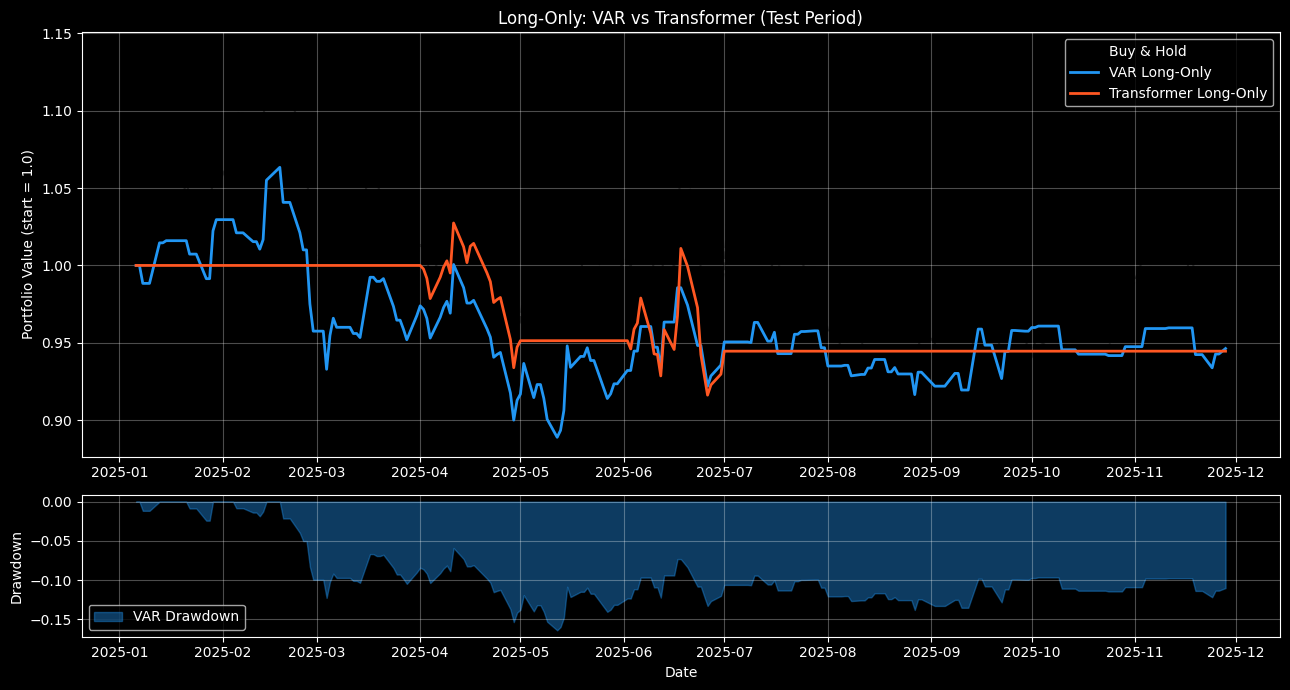

Saved: /Users/mathewmartin/Library/CloudStorage/GoogleDrive-mm14460@nyu.edu/My Drive/05 Spring 2026/VIP GY 5000 Portfolio Management/plots/long_only_equity_curve.png

evaluate() return dict (VAR primary model):
  cumulative_return     : -0.0537
  annual_return         : -0.0594
  sharpe_ratio          : -0.2497
  max_drawdown          : -0.164
  num_trades            : 123
  win_rate              : 0.4729


In [27]:
# Instantiate and fit on training data
strategy = LongOnlyStrategy(task_type='strategy')
strategy.fit(X_train_sc, y_train)

# evaluate() calls predict() internally — do NOT call predict() separately
metrics = strategy.evaluate(X_test_sc, y_test)

print("\nevaluate() return dict (VAR primary model):")
for k, v in metrics.items():
    print(f"  {k:<22}: {v}")


## 10. Signal Distribution (Both Models)

Side-by-side bar charts showing how many test-period days each model spent long vs flat. A heavily flat Transformer confirms class collapse.

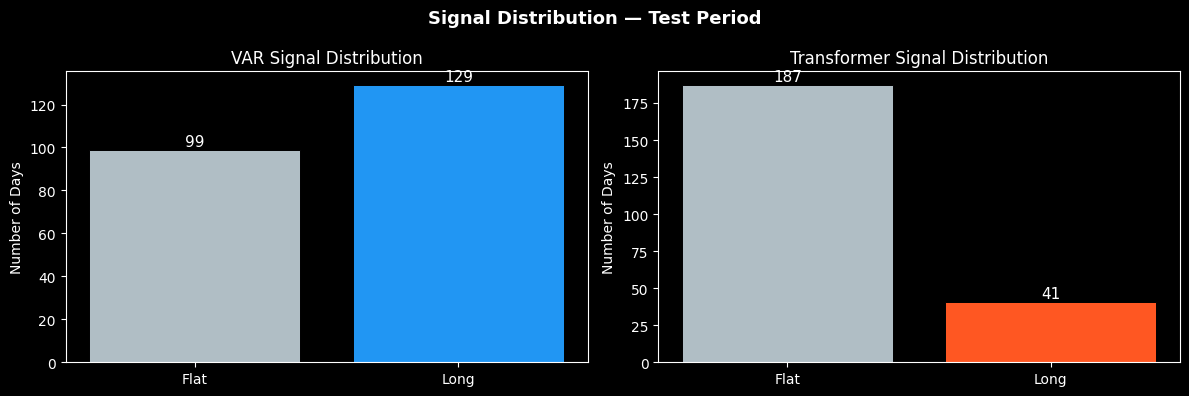

Saved: /Users/mathewmartin/Library/CloudStorage/GoogleDrive-mm14460@nyu.edu/My Drive/05 Spring 2026/VIP GY 5000 Portfolio Management/plots/long_only_signal_dist.png


In [28]:
# Side-by-side signal distribution for both models
MONTH_NAMES_MAP = {-1: 'Short', 0: 'Flat', 1: 'Long'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left panel: VAR signal distribution
var_counts = pd.Series(strategy.var_signals_).value_counts().sort_index()
var_labels = [MONTH_NAMES_MAP.get(i, str(i)) for i in var_counts.index]
axes[0].bar(var_labels, var_counts.values, color=['#B0BEC5', '#2196F3'],
            edgecolor='black', linewidth=0.7)
axes[0].set_title('VAR Signal Distribution')
axes[0].set_ylabel('Number of Days')
for bar, val in zip(axes[0].patches, var_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontsize=11)

# Right panel: Transformer signal distribution
tf_counts = pd.Series(strategy.tf_signals_).value_counts().sort_index()
tf_labels = [MONTH_NAMES_MAP.get(i, str(i)) for i in tf_counts.index]
axes[1].bar(tf_labels, tf_counts.values, color=['#B0BEC5', '#FF5722'],
            edgecolor='black', linewidth=0.7)
axes[1].set_title('Transformer Signal Distribution')
axes[1].set_ylabel('Number of Days')
for bar, val in zip(axes[1].patches, tf_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontsize=11)

fig.suptitle('Signal Distribution — Test Period', fontsize=13, fontweight='bold')
plt.tight_layout()
path = os.path.join(PROJ_ROOT, 'plots', 'long_only_signal_dist.png')
plt.savefig(path, dpi=150); plt.show()
print(f"Saved: {path}")


## 11. Monthly Returns Heatmap (VAR Strategy)

Calendar-style grid of monthly P&L for the VAR Long-Only strategy. Uses `strategy.var_returns_` populated by `evaluate()`.

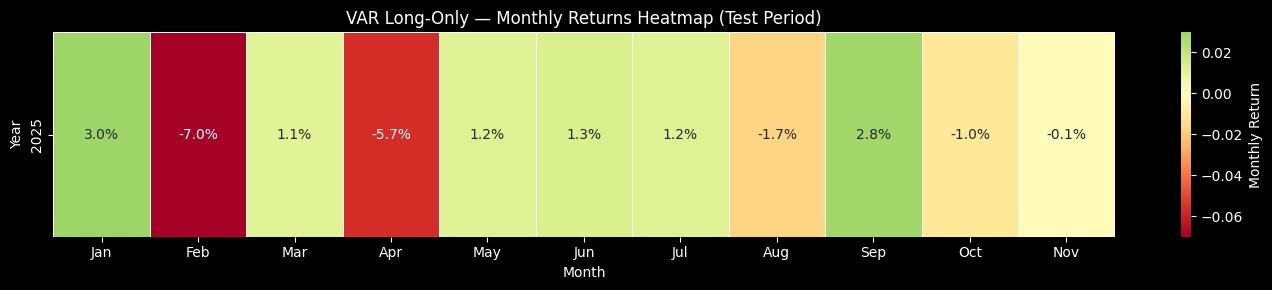

Saved: /Users/mathewmartin/Library/CloudStorage/GoogleDrive-mm14460@nyu.edu/My Drive/05 Spring 2026/VIP GY 5000 Portfolio Management/plots/long_only_monthly_heatmap.png


In [29]:
# Monthly returns heatmap — VAR strategy, calendar-style grid
MONTH_NAMES = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

strat_ret   = strategy.var_returns_
monthly_ret = (strat_ret + 1).resample('ME').prod() - 1
pivot = pd.DataFrame({'Year':   monthly_ret.index.year,
                       'Month':  monthly_ret.index.month,
                       'Return': monthly_ret.values}
               ).pivot(index='Year', columns='Month', values='Return')
pivot.columns = [MONTH_NAMES[m] for m in pivot.columns]

fig, ax = plt.subplots(figsize=(14, max(3, len(pivot) * 0.7)))
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Monthly Return'})
ax.set_title('VAR Long-Only — Monthly Returns Heatmap (Test Period)')
ax.set_xlabel('Month'); ax.set_ylabel('Year')
plt.tight_layout()
path = os.path.join(PROJ_ROOT, 'plots', 'long_only_monthly_heatmap.png')
plt.savefig(path, dpi=150); plt.show()
print(f"Saved: {path}")


## 12. Advantages & Limitations

### Advantages
- **Downside protection**: flat during predicted down days reduces drawdown
  vs buy-and-hold and vs long-short.
- **Implementable**: wheat futures are liquid; no short-selling margin needed.
- **Macro-conditioned signal**: VAR uses FEDFUNDS, GS10, BAA, TB3MS —
  economically justified predictors of commodity market conditions.
- **Model comparison**: VAR vs Transformer side-by-side reveals how signal
  quality translates directly into real trading outcomes.

### Limitations
- **Opportunity cost**: flat periods earn nothing; false Down signals miss gains.
- **Near-random signal**: VAR test accuracy ~53%; small edge is sensitive to
  transaction costs not modelled here.
- **No position sizing**: full unit position regardless of signal confidence.
- **Transformer class collapse**: Transformer may predict Down on most days
  due to class imbalance during training (no pos_weight). Observable in the
  signal distribution plot — itself a meaningful finding.


## 13. Save & Load Verification

Pickle the strategy (var_model + signal arrays), reload, re-attach the Transformer (not pickled — contains non-serialisable PyTorch objects), and assert VAR signals are bit-for-bit identical.

In [30]:
# Save strategy artefacts to disk
model_path = os.path.join(BASE, 'long_only_strategy.pkl')
strategy.save(model_path)

# Reload from pickle
strategy2 = LongOnlyStrategy(task_type='strategy')
strategy2.load(model_path)
strategy2.transformer = transformer   # re-attach (not pickled — non-serialisable)

# Verify VAR signals are bit-for-bit identical
orig_sigs   = strategy.predict(X_test_sc)
reload_sigs = strategy2.predict(X_test_sc)
match = np.array_equal(orig_sigs, reload_sigs)
print(f"Loaded model VAR signals match original: {match}")
assert match, "Save/load verification failed!"
print("Save & load verified successfully.")


Strategy saved to /Users/mathewmartin/Library/CloudStorage/GoogleDrive-mm14460@nyu.edu/My Drive/05 Spring 2026/VIP GY 5000 Portfolio Management/models/long_only_strategy.pkl
Strategy loaded from /Users/mathewmartin/Library/CloudStorage/GoogleDrive-mm14460@nyu.edu/My Drive/05 Spring 2026/VIP GY 5000 Portfolio Management/models/long_only_strategy.pkl
NOTE: Re-attach transformer after load: strategy.transformer = transformer
Loaded model VAR signals match original: True
Save & load verified successfully.
